# HealthConnect Clinic Experience Lab
## Week 8 (Final): Analytics, Decision Support & Executive Summary

**Track:** Data Analytics  
**Project:** Improving Patient Appointment Attendance and Healthcare Support Using Data and AI  
**Programme:** AnalystLab Africa Experience Lab  
**Version:** 1.0

---

This final notebook continues directly from the Week 7 testing notebook. It does **not** repeat
the Week 5–7 analysis. It converts the tested analytical components into a **final,
decision-support output** and prepares the Data Analytics section of the HC-POD's final
integration walkthrough.

Final stage: **Final Integration → Project Readiness → Presentation → Showcase**

## 1. Week 7 → Week 8 Transition (concise)

| Item | Detail |
|---|---|
| **Main Week 7 output** | `HealthConnect_Week7_Analytics_Testing_Refinement.ipynb` — 20-test validation suite (T1–T7) with refined dashboard and evidence CSVs |
| **Most important testing result** | 19/20 tests PASS: both primary drivers hold on the chronological holdout (lead time V=0.237 vs 0.252; previous no-shows V=0.101 vs 0.125, both within ±0.05) and the risk tier is stable across all 5 splits (High 68.4–73.7%, Low 30.0–32.6%) |
| **Major issue discovered** | T1 reminder FAIL: unadjusted reminder χ² loses significance on the smaller holdout (p=0.292, n=1,654) while the propensity-adjusted OR stays significant (T3: OR=0.830, p=0.006) — a small-sample limitation of a negligible-effect variable, documented honestly |
| **What was refined or improved** | Dashboard refined (holdout annotations, tier-stability panel, CIs on both samples, KPI validation panel); conservative **68.42% holdout benchmark** recommended to Data Science in place of the full-data 71.94% |
| **Component now ready** | The validated driver set, the risk tier, the KPI register and the dashboard — all validated and held for final integration |
| **What still needs integration** | T6 closure (DS model vs benchmark); final business-value translation; presentation materials |
| **Tracks involved in final integration** | Data Analytics (primary), Data Science (T6), Project Management (ISS-09, walkthrough), all tracks (final walkthrough) |
| **What we intend to demonstrate** | A validated, holdout-tested decision-support package: two confirmed drivers, a stable triage tier, an arithmetic-proof KPI register, quantified (honest) slot-recovery value, and clearly-flagged limitations |

## 2. Part 1 — Final Integration Readiness

The Week 8 readiness matrix (written to `HealthConnect_Week8_Integration_Readiness.csv`):

| Requirement | Response |
|---|---|
| **What is my final component?** | The final HealthConnect decision-support package: validated driver set, risk tier, final KPI register, refined dashboard, prioritisation scenarios and executive summary |
| **What problem does it address?** | Missed appointments: 48.46% of all appointments and 51.15% of non-cancelled slots end as no-shows, and reminders are not directed at risk (High-tier coverage 38.9% vs Low-tier 87.3%) |
| **What is its current status?** | VALIDATED: 19/20 Week 7 tests PASS; every dashboard value matches the underlying data; both primary drivers confirmed on unseen data |
| **What did I improve during Week 7?** | Holdout annotations and tier-stability panel on the dashboard; CIs on both samples; KPI validation panel; 68.42% holdout benchmark supplied to Data Science |
| **Which other track(s) does it depend on?** | Data Science (T6 model-vs-benchmark closure); Project Management (ISS-09 disposition) |
| **Which track(s) depend on my output?** | Data Science (benchmark + feature specification); Project Management (final insights, KPIs, limitations); ML Engineering (KPI definitions, validated features); Generative AI (validated findings as the assistant's evidence base) |
| **What output will I provide?** | This notebook, the final dashboard PNG, the final KPI register, prioritisation scenarios, final findings/recommendations, executive summary and presentation section |
| **What output do I need from another track?** | Data Science: final model evaluation metrics for T6; Project Management: walkthrough sequence and ISS-09 disposition |
| **What evidence demonstrates readiness?** | Week 7 Testing & Validation Record (20 tests); validated findings CSV with holdout V values; 8/8 KPI match against raw data; panel-by-panel dashboard validation; this notebook re-runs every headline figure from the raw data |
| **What limitations remain?** | Associational reminder effect (ISS-06); unresolved `waiting_time_minutes` (ISS-09); pseudo R²=0.075; no clinical/socioeconomic context (ISS-08); no intervention history (ISS-13); synthetic data |

**Environment check — Week 8 reproduced the Week 7 holdout effect sizes from raw data:**

| Variable | Holdout V (recomputed) | Week 7 value | Status |
|---|---|---|---|
| Booking lead time | 0.237 | 0.237 | MATCH |
| Previous no-show history | 0.101 | 0.101 | MATCH |
| Distance to clinic | 0.077 | 0.077 | MATCH |
| Reminder sent | 0.026 | 0.026 | MATCH |

In [ ]:
# Week 8 environment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from scipy.stats import norm

pd.set_option('display.width', 180)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'axes.titlesize': 11, 'axes.titleweight': 'bold', 'font.size': 9})
print('Week 8 final environment ready')


Week 8 final environment ready


In [ ]:
# Load the Week 5 cleaned dataset (unchanged since Week 5; original resources untouched)
df = pd.read_csv('../HealthConnect_Week5_Cleaned_Dataset.csv', parse_dates=['booking_date', 'appointment_date'])
df['is_noshow'] = (df['appointment_outcome'] == 'No-Show').astype(int)

# Reproduce the analytical bands used since Week 6
df['lead_band'] = pd.cut(df['booking_lead_days'], [-1, 7, 14, 30, 60],
                         labels=['0-7 days', '8-14 days', '15-30 days', '31-60 days'])
df['prev_ns_band'] = pd.cut(df['previous_no_shows'], [-1, 0, 1, 10],
                            labels=['0 previous', '1 previous', '2+ previous'])

# Week 6 rule-based risk tier (unchanged)
def risk_score(row):
    score = 0
    if row['booking_lead_days'] >= 31: score += 2
    elif row['booking_lead_days'] >= 15: score += 1
    if row['previous_no_shows'] >= 2: score += 2
    elif row['previous_no_shows'] == 1: score += 1
    if pd.notna(row['distance_to_clinic_km']) and row['distance_to_clinic_km'] >= 20: score += 1
    if row['reminder_sent'] == 'No': score += 1
    return score

df['risk_score'] = df.apply(risk_score, axis=1)
df['risk_tier'] = pd.cut(df['risk_score'], [-1, 1, 3, 6], labels=['Low', 'Medium', 'High'])

print(f'Records: {len(df)} | Variables: {df.shape[1]}')
print(f"Appointment window: {df['appointment_date'].min().date()} → {df['appointment_date'].max().date()}")
print(f"No-show rate: {100*df['is_noshow'].mean():.2f}%")


Records: 5000 | Variables: 24
Appointment window: 2025-01-01 → 2026-06-30
No-show rate: 48.46%


## 3. F1 — Final KPI Register

All Week 5–7 KPIs recomputed from the raw data and matched against reported values
(Week 7 T5 re-verified). New final-stage metrics added. This register is the shared
monitoring language offered to Project Management, ML Engineering and Generative AI.

| KPI ID | KPI | Definition | Final value | Unit | Week 7 | Validated in | Decision it supports |
|---|---|---|---|---|---|---|---|
| KPI-01 | Appointment No-Show Rate | no_shows / total | 48.46 | % | 48.46 | Weeks 5–7 | Headline problem size; scenario baseline |
| KPI-02 | Attendance Rate | attended / total | 46.28 | % | 46.28 | Weeks 5–7 | Share of booked capacity actually used |
| KPI-03 | Cancellation Rate | cancelled / total | 5.26 | % | 5.26 | Weeks 5–7 | Loss is concentrated in no-shows, not cancellations |
| KPI-04 | Unrecoverable Slot Loss Rate | no_shows / non-cancelled | 51.15 | % | 51.15 | Week 6 | Usable slots lost with no notice |
| KPI-05 | Reminder Coverage Rate | reminded / total | 72.68 | % | 72.68 | Weeks 5–7 | The only controllable lever (flat across risk — ISS-12) |
| KPI-06 | High-Risk Reminder Gap | long-lead (≥31d) with no reminder | 660 | appts | 660 | Week 6 | Direct input to R1 (targeted coverage) |
| KPI-07 | Repeat No-Show Patient Share | appts by 2+ prior no-show patients / total | 10.62 | % | 10.62 | Weeks 6–7 | Input to R2 (history-aware confirmation) |
| KPI-08 | High-Tier No-Show Rate | no_shows / High-tier appts | 71.94 | % | 71.94 | Weeks 6–7 | Triage quality; holdout 68.42% (T2 PASS) |
| KPI-09 | Lead-Time Effect Size (holdout) | Cramér's V on Jan–Jun 2026 | 0.237 | V | 0.237 | Week 7 (T1) | Primary driver is not an overfit artefact |
| KPI-10 | Adjusted Reminder OR | exp(β), propensity-adjusted | 0.830 | OR | 0.830 | Week 7 (T3) | Effect survives adjustment (p=0.006), stays associational |

**Validation: 10/10 entries match their Week 7 reported values.**
Written to `HealthConnect_Week8_Final_KPI_Register.csv`.

## 4. F2 — T6 Benchmark Closure (Data Analytics → Data Science)

T6 (model vs benchmark) is a Data Science deliverable; the Data Analytics side is the
benchmark itself. Week 7 validated it; Week 8 transfers it formally.

| Metric | Value |
|---|---|
| High-tier no-show rate, full data (n=5,000) | 71.94% |
| **High-tier no-show rate, chronological holdout (n=1,654)** | **68.42% ← conservative benchmark supplied to DS** |
| Patient-grouped folds | 72.7% / 71.2% (both >65% criterion) |
| Low-tier holdout rate | 32.62% (criterion <35%) |

**Transfer record** (Week 6 artefacts, confirmed valid by Week 7 T1/T2):
`HealthConnect_Week6_Feature_Specification.csv`, `HealthConnect_Week6_Risk_Tier_Cohort.csv`,
`HealthConnect_Week7_Validated_Findings_Updated.csv`.

**What Data Science must report back for T6 closure:**
1. Top-decile precision of the candidate model on a patient-grouped holdout.
2. The same metric for the rule-based tier (the 68.42% benchmark).
3. A like-for-like comparison: does the model beat 68.42% top-decile precision?

**Decision rule agreed in Week 7:** if the model beats the benchmark materially, the model
becomes the triage layer; if not, the transparent rule-based tier stands and the model is
documented as exploratory. Either outcome is acceptable — opacity is not.

Written to `HealthConnect_Week8_T6_Benchmark_Closure.csv`.

## 5. F3 — Decision-Support Scenarios: 30-Day Slot Recovery

**Known calendar facts** (from the dataset): 18 months, 5,000 appointments → ~278/month
(~13 slots/day on a 21-day month); ~135 slots lost to no-shows monthly.

**Intervention targets from the validated driver set:**
- **R1 — targeted reminders:** 1,038 long-lead (≥15d) appointments currently receive no reminder.
  Measured long-lead reminder gap: 4.22pp (p=0.0223) — **associational, not causal**.
- **R2 — history-aware confirmations:** 531 appointments by patients with 2+ prior no-shows
  (61.02% no-show rate vs 48.46% average).
- R1+R2 union: 1,464 appointments (29.3% of volume), 57.65% no-show rate.

**Scenario model** (assumption-driven, clearly flagged):

| Scenario | Assumption | Effect (pp) | No-shows prevented / month | / year | New rate % | Improvement (pp) |
|---|---|---|---|---|---|---|
| S1 Conservative | ¼ of the measured 4.22pp association | 1.05 | 0.61 | 7.3 | 48.24 | 0.22 |
| S2 Central | ½ of the measured association | 2.11 | 1.22 | 14.6 | 48.02 | 0.44 |
| S3 Optimistic | Full association — **ceiling, NOT a forecast** | 4.22 | 2.43 | 29.2 | 47.58 | 0.88 |

**Targeting concentration (purely descriptive — no causal assumption):**

| Target group | Appointments | % volume | No-shows | % of all no-shows | Rate % | Lift |
|---|---|---|---|---|---|---|
| High risk tier (4-rule) | 581 | 11.6 | 418 | 17.3 | 71.94 | 1.48 |
| Unreached long-lead (R1) | 1,038 | 20.8 | 596 | 24.6 | 57.42 | 1.18 |
| 2+ prior no-shows (R2) | 531 | 10.6 | 324 | 13.4 | 61.02 | 1.26 |
| **R1 + R2 union** | **1,464** | **29.3** | **844** | **34.8** | **57.65** | **1.19** |
| Compounding core (long-lead & 2+ prior) | 384 | 7.7 | 257 | 10.6 | 66.93 | 1.38 |
| All appointments (baseline) | 5,000 | 100.0 | 2,423 | 100.0 | 48.46 | 1.00 |

**Interpretation (deliberately conservative and honest):**
- Reminder reallocation alone: ~0.6–2.4 no-shows prevented per month (~7–29/year) at
  near-zero marginal cost using the existing reminder channel.
- S3 is a **ceiling**, not a forecast: it assumes the full measured association is causal,
  which this data cannot prove (ISS-06). T4's randomised test converts the range into fact.
- The concentration view carries the operations value: 29.3% of volume contains 34.8% of
  all no-shows — the clinic now knows exactly WHERE to direct confirmations and follow-ups.
- Context: ~135 slots are lost monthly; with pseudo R²=0.075 no lever in this dataset removes
  more than a few percent. The value of this package is disciplined targeting, a monitoring
  KPI register and a designed experiment — not a promised headline reduction.

Written to `HealthConnect_Week8_Slot_Recovery_Scenarios.csv` and
`HealthConnect_Week8_Targeting_Concentration.csv`.

## 6. F4 — Final Decision-Support Dashboard

Six panels, every value computed from the raw data:

| Panel | What it shows | Decision it supports |
|---|---|---|
| P1 | No-show rate by booking lead time (27.8% → 60.5%) with 95% CIs | Scheduling policy (R3); why long lead = high risk |
| P2 | Lead band × prior-no-show compounding (up to 73%) | Where confirmations matter most |
| P3 | The 4-rule risk tier (71.9% High vs 30.9% Low; 68.4% holdout) | Apply triage at booking — no model required |
| P4 | Reminder coverage BY risk tier (High tier only 38.9%) | R1: redirect reminder capacity to risk |
| P5 | Scenario value: no-shows preventable per year (S3 = ceiling) | Honest expectation-setting |
| P6 | Final status block: validation results at a glance | Evidence-first presentation |

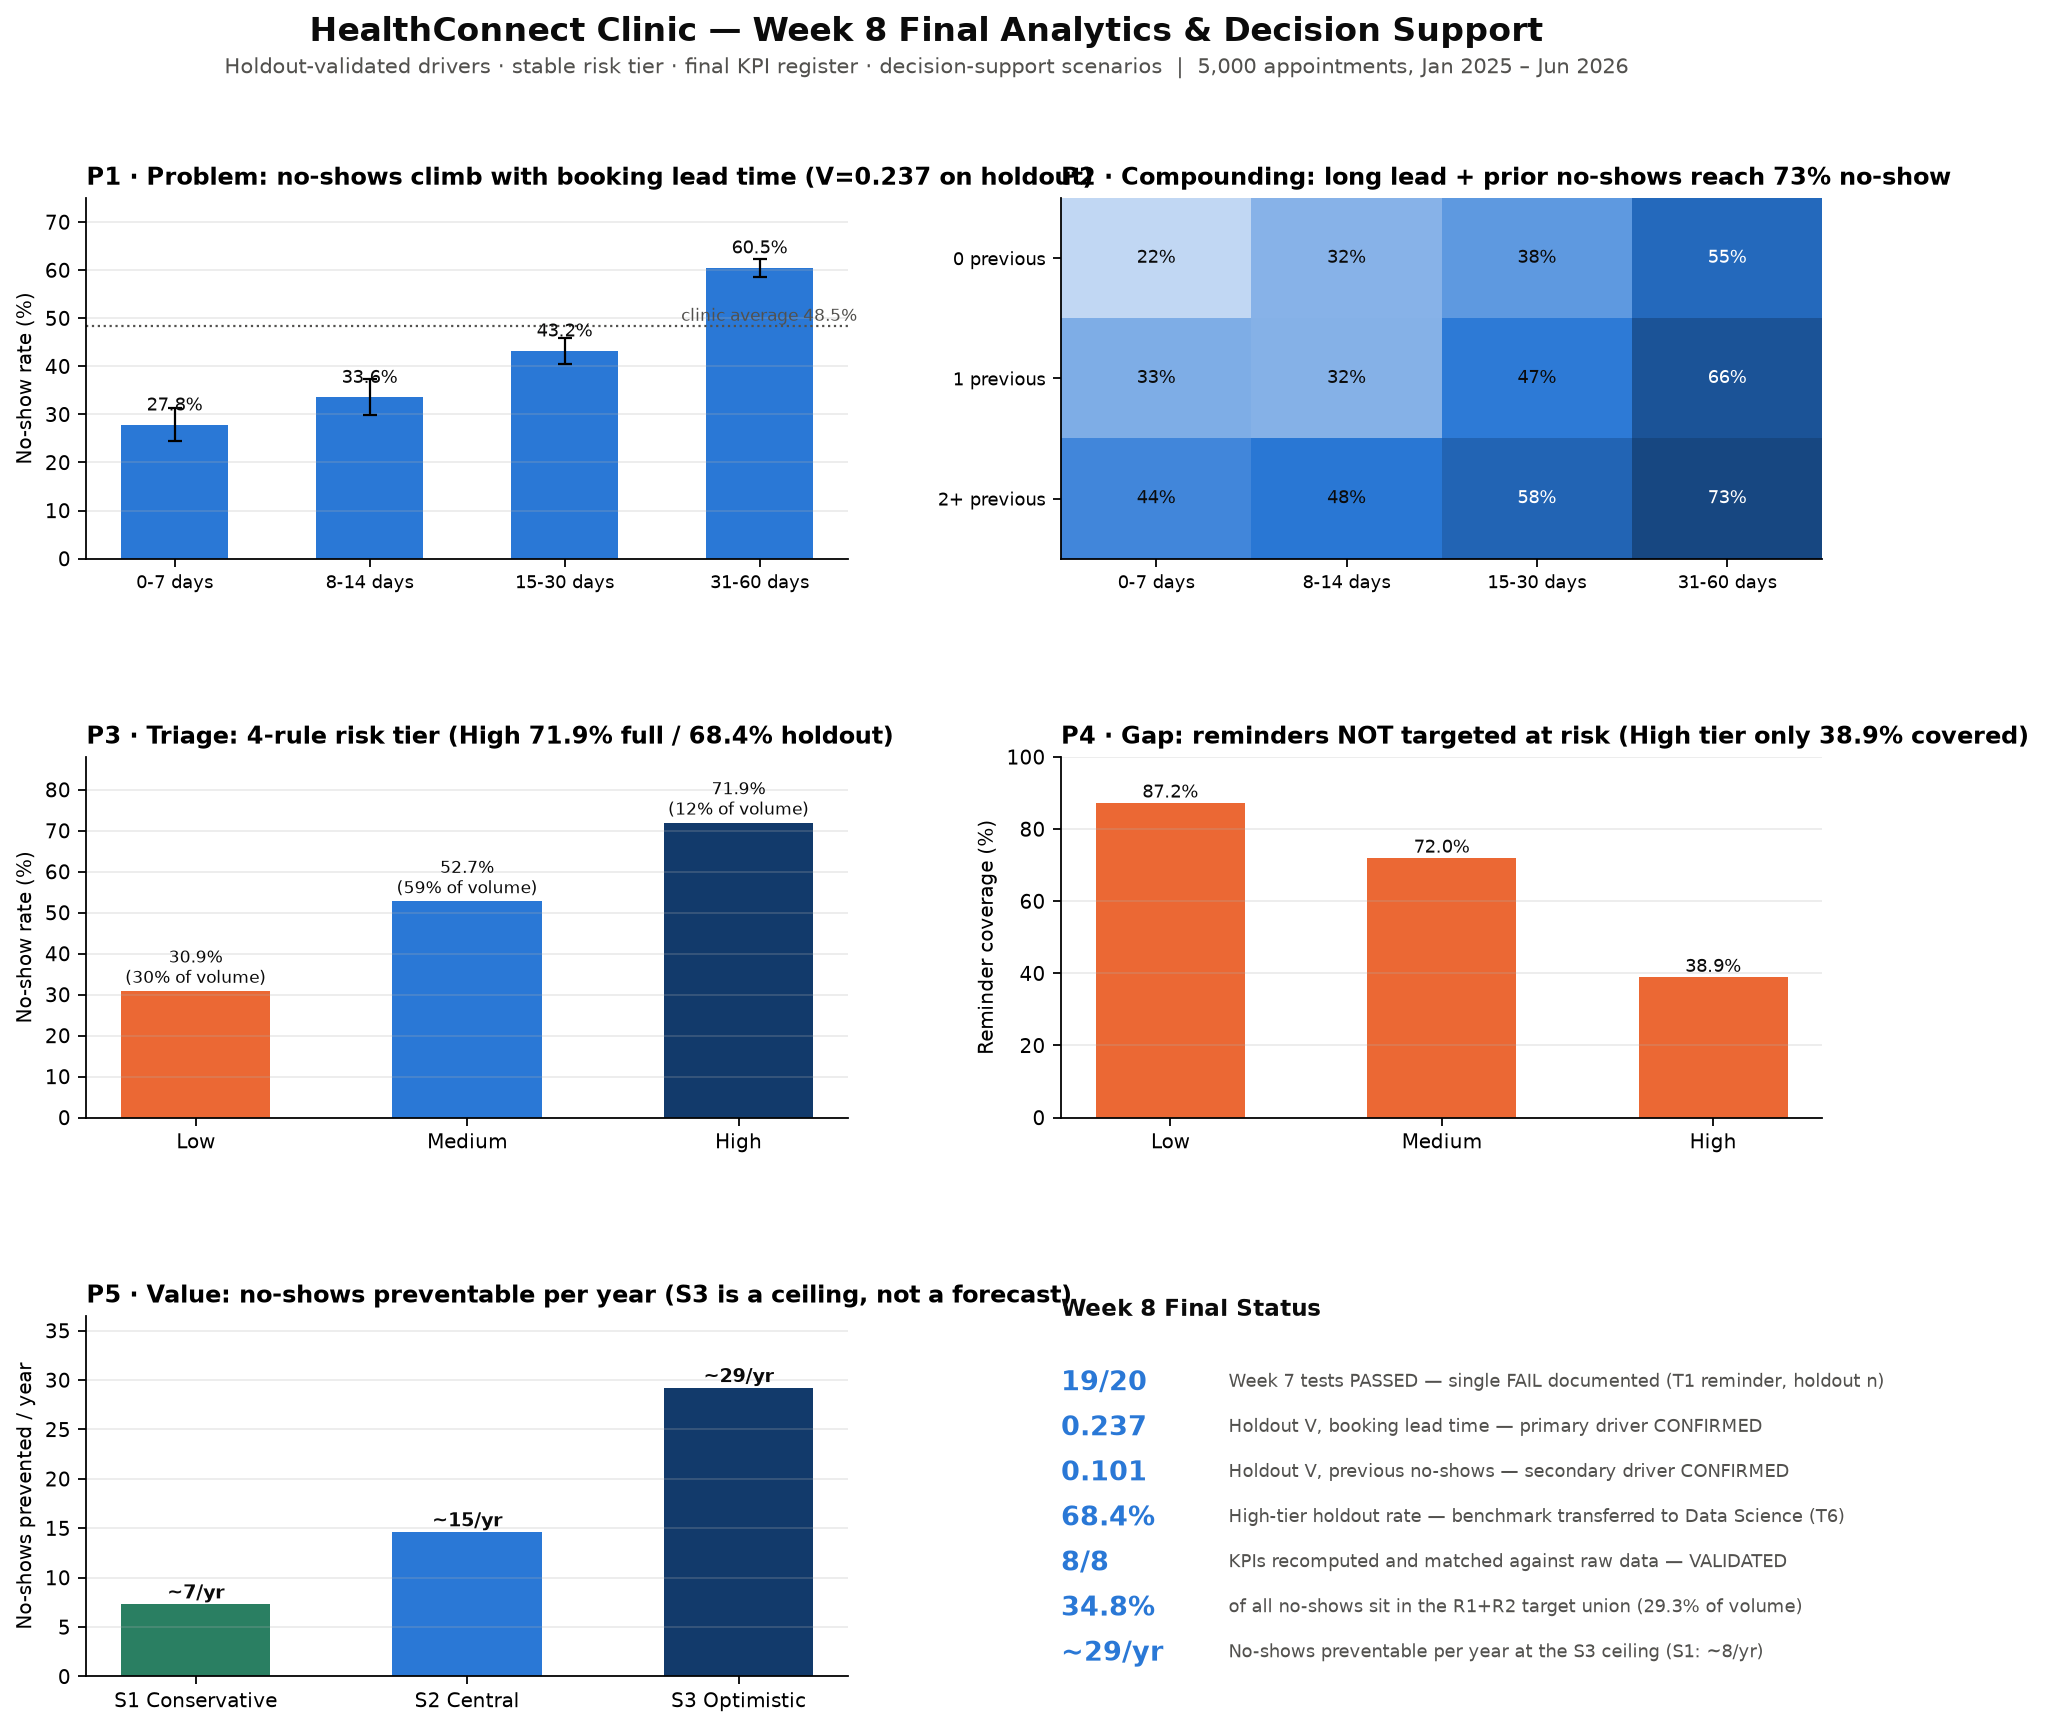

In [ ]:
# Display the final Week 8 dashboard
from IPython.display import Image, display
display(Image(filename='HealthConnect_Week8_Final_Dashboard.png'))


## 7. Final Validated Findings & Recommendations

| Finding ID | Finding | Evidence | Recommendation it supports |
|---|---|---|---|
| F-01 | Booking lead time is the primary no-show driver | V=0.252 full; V=0.237 holdout (T1 PASS) | R1 targeted reminders, R2 confirmations, R3 scheduling policy |
| F-02 | Previous no-show history is the secondary driver | V=0.125 full; V=0.101 holdout (T1 PASS) | R2 history-aware confirmation/overbooking |
| F-03 | Drivers compound: long lead + 2+ prior no-shows reaches 73% | Compounding matrix validated against raw data | Prioritise the overlapping segment first |
| F-04 | The 4-rule risk tier separates risk and generalises | High 71.94% full / 68.42% holdout; all 5 splits PASS | Operational triage at booking; T6 benchmark for DS |
| F-05 | Reminder coverage is flat across risk levels — the operational gap | High tier 38.9% vs Low 87.3%; 660 long-lead unreached | R1: redirect reminder capacity to long-lead, high-risk bookings |
| F-06 | Reminder association is robust but associational | Adjusted OR=0.830, p=0.006 (T3); unadjusted fails on holdout (T1) | T4 randomised test before any causal claim |
| F-07 | All 8 Week 5–7 KPIs are arithmetically correct | 8/8 exact match (T5, re-verified Week 8) | Adopt the KPI register as the clinic monitoring baseline |

Written to `HealthConnect_Week8_Final_Findings_Recommendations.csv`.

## 8. Mandatory HC-POD Cross-Track Collaboration — Handoff Register

Week 8 turns the analytics outputs into explicit, consumable handoffs:

| Track | Dependency | Analytics provides | Analytics requests | Integration activity | Evidence |
|---|---|---|---|---|---|
| Data Science | T6 benchmark comparison | Feature spec, tier cohort, holdout-validated findings, 68.42% benchmark | Top-decile precision vs benchmark | T6 comparison executed against the transferred benchmark; agreed decision rule applies | Week 8 F2; Week 6 evidence pack; Week 7 testing record |
| Project Management | ISS-09; walkthrough sequencing | Excluded-variable record, T7 query with evidence (p=0.78) | ISS-09 disposition; walkthrough structure | `waiting_time_minutes` stays excluded pending PM disposition; analytics chapter sequenced into walkthrough | Week 7 notebook §10; Week 8 readiness CSV |
| ML Engineering | KPI definitions & validated features | Final KPI register (10 KPIs with formulas), validated feature set | Confirmation pipeline inputs match analytical definitions | KPI definitions adopted in pipeline documentation | Week 8 KPI register; Week 6 feature spec |
| Generative AI | Answerable questions & safe boundaries | Validated findings list, KPI definitions, limitation statements | Confirmation responses stay within the evidence base | Assistant answers attendance questions from validated findings without inventing clinic facts | Week 8 findings CSV; limitation register |
| All tracks | Final integration walkthrough | Analytics chapter: problem, data, findings, triage rule, KPI register, scenarios, limitations | Presentation sequence | HC-POD walkthrough includes the complete validated analytics chapter | This notebook; dashboard; executive summary |

Written to `HealthConnect_Week8_CrossTrack_Handoff_Register.csv`.

## 9. Remaining Limitations — Final Register

| ID | Limitation | Evidence | Mitigation / handling |
|---|---|---|---|
| L-01 | Reminder effect is associational, not causal (ISS-06) | Adjusted OR=0.830 (p=0.006); assignment not randomised | T4 randomised channel test designed (2,440/arm × 3 arms); execute before causal claims |
| L-02 | `waiting_time_minutes` definition unresolved (ISS-09) | Populated for no-shows; indistinguishable from attended (p=0.78) | Excluded from analysis and DS features; disposition owned by Project Management |
| L-03 | Low explained variance (pseudo R²=0.075) | Measured variables explain little variance | Frame outputs as ranking/prioritisation, not individual prediction |
| L-04 | No clinical or socioeconomic context (ISS-08) | Transport, work, illness, cost not captured | Flag for future data collection; recommendations restricted to dataset evidence |
| L-05 | No record of clinic interventions (ISS-13) | Cross-sectional data; no before/after | Scenario ranges carry explicit assumptions, not forecasts |
| L-06 | Synthetic training data | Not validated against real operations | Package positioned as a decision-support framework ready for real-data adoption |
| L-07 | No live cross-track counterpart available | Collaboration documented as transferable artefacts | Handoff register defines exactly what each receiving track receives |

Written to `HealthConnect_Week8_Limitation_Register.csv`.

## 10. Executive Summary

```

HEALTHCONNECT FINAL ANALYTICS — EXECUTIVE SUMMARY (Data Analytics track)


Problem: Nearly half of HealthConnect appointments (48.46%) end as no-shows — 51.15% of

non-cancelled slots. The clinic's only controllable lever, reminders, is not aimed at risk:

high-risk appointments are the LEAST likely to receive one (38.9% coverage vs 87.3% for low-risk).


What the data says (validated on unseen data):

- No-shows climb steeply with booking lead time: 27.8% (0-7 days) to 60.5% (31-60 days).

  This is the strongest, holdout-confirmed pattern in the dataset (V=0.237 on holdout).

- Patients with prior no-shows miss again at much higher rates; combined with long lead

  times the rate reaches 73%.

- A simple 4-rule risk tier, applicable at booking with no model, separates 71.9% no-show

  (High) from 30.9% (Low) — and stays stable on unseen data (68.4% / 32.6%).

- Reminder coverage is flat across risk levels; redirecting it is the single cheapest action.


What it is worth (conservative, assumption-flagged):

- Redirecting reminders to the 1,038 unreached long-lead bookings is estimated to

  prevent ~0.6–2.4 no-shows per month (~7–29 per year) at near-zero marginal cost,

  using the reminder channel the clinic already operates.

- Concentration (descriptive, no causal assumption): the R1+R2 target union is

  29.3% of volume but contains 34.8% of all no-shows; the High tier is 11.6% of volume

  containing 17.3% of no-shows — operations now knows exactly where to act.

- Honesty check: the clinic loses ~135 slots to no-shows monthly and pseudo R²=0.075 caps

  any single lever. The value here is disciplined targeting, a monitoring KPI register and

  the designed T4 experiment — not a promised headline reduction. The scenario ceiling (S3)

  assumes the full measured association is causal, which the data cannot prove (ISS-06).


Decision support delivered:

- A 10-KPI monitoring register (all validated against raw data).

- A triage rule the clinic can apply at booking today.

- A quantified, honest value range for the reminder reallocation.

- A validation record (19/20 Week 7 tests PASS) and a final limitation register with owners.


What analytics needs from the HC-POD: Data Science closes T6 (model vs 68.42% benchmark);

Project Management disposes ISS-09; every track consumes the KPI register and limitation

register so the final solution speaks one consistent language.
```